In [1]:
# model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
from torch import optim 
from torch.optim.lr_scheduler import StepLR

# dataset and transformation
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

# display images
from torchvision import utils
import matplotlib.pyplot as plt

# utils
import numpy as np
import time
import copy

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# GPU 이름 출력
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Load Dataset : STL10
# specify the data path
path2data = './rdata'

# if not exists the path, make the directory
if not os.path.exists(path2data):
    os.mkdir(path2data)

# load dataset
train_ds = datasets.STL10(path2data, split='train', download=True, transform=transforms.ToTensor()) # 5000장
val_ds = datasets.STL10(path2data, split='test',download=True, transform=transforms.ToTensor()) # 8000장

print(len(train_ds))
print(len(val_ds))

Using device: cuda
GPU: NVIDIA TITAN Xp
Files already downloaded and verified
Files already downloaded and verified
5000
8000


In [3]:
# caculate mean & std
# dataset : caculate mean & std
# to normalize the dataset, calculate the mean and std
train_meanRGB = [np.mean(x.numpy(), axis=(1,2)) for x, _ in train_ds]
train_stdRGB = [np.std(x.numpy(), axis=(1,2)) for x, _ in train_ds]

train_meanR = np.mean([m[0] for m in train_meanRGB])
train_meanG = np.mean([m[1] for m in train_meanRGB])
train_meanB = np.mean([m[2] for m in train_meanRGB])
train_stdR = np.mean([s[0] for s in train_stdRGB])
train_stdG = np.mean([s[1] for s in train_stdRGB])
train_stdB = np.mean([s[2] for s in train_stdRGB])

val_meanRGB = [np.mean(x.numpy(), axis=(1,2)) for x, _ in val_ds]
val_stdRGB = [np.std(x.numpy(), axis=(1,2)) for x, _ in val_ds]

val_meanR = np.mean([m[0] for m in val_meanRGB])
val_meanG = np.mean([m[1] for m in val_meanRGB])
val_meanB = np.mean([m[2] for m in val_meanRGB])

val_stdR = np.mean([s[0] for s in val_stdRGB])
val_stdG = np.mean([s[1] for s in val_stdRGB])
val_stdB = np.mean([s[2] for s in val_stdRGB])

print(train_meanR, train_meanG, train_meanB)
print(val_meanR, val_meanG, val_meanB)

0.4467106 0.43980986 0.40664646
0.44723064 0.4396425 0.40495726


In [4]:
# define the image transformation 
train_transformation = transforms.Compose([
    transforms.RandAugment(num_ops=2, magnitude=10),
    transforms.ToTensor(),
    transforms.Resize(224), # ResNet이 224x224로 설계가 되어있기 때문이다. -> 최종적으로 1x1로 딱 떨어지게 됨(원래 원본은 96)
    transforms.Normalize([train_meanR, train_meanG, train_meanB], [train_stdR, train_stdG, train_stdB]),
    transforms.RandomHorizontalFlip()
])

val_transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(224),
    transforms.Normalize([train_meanR, train_meanG, train_meanB], [train_stdR, train_stdG, train_stdB]),
])

# apply transformation
train_ds.transform = train_transformation
val_ds.transform = val_transformation

# create DataLoader
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9929461..2.6500857].


image indices:  [ 235 3980  905 2763 2895  144 4225 2797]


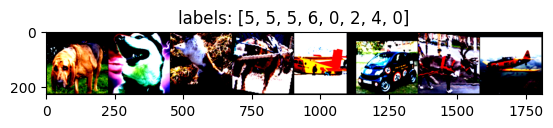

In [5]:
# image grid display
def show(img, y=None, color=True): # y:label
    npimg = img.numpy() # tensor -> numpy
    npimg_tr = np.transpose(npimg, (1,2,0)) # 차원 순서 변경(Pytorch의 경우 : [C,H,W], matplotlib의 경우 : [H,W,C])
    plt.imshow(npimg_tr) # 이미지 화면에 표시

    if y is not None: # 라벨이 있을 때만 실행
        plt.title('labels: '+ str(y)) # 이미지 위에 라벨 표시

# 랜덤 고정(매번 같은 이미지 선택 - 재현성)
np.random.seed(1) # numpy 랜덤 고정
torch.manual_seed(1) # pytorch 랜덤 고정

# train_dataset에서 8개 데이터 랜덤하게 선정
grid_size=8
rnd_inds = np.random.randint(0, len(train_ds), grid_size) # 0~5000 사이에서 랜덤하게 8개 인덱스 선택
print('image indices: ', rnd_inds)

# 샘플 이미지와 라벨 추출(train_ds[i]는 튜플이라 train_ds[i][0] : 이미지, train_ds[i][1] : 라벨)
x_grid = [train_ds[i][0] for i in rnd_inds] # 데이터셋 : 이미지 데이터 8개
y_grid = [train_ds[i][1] for i in rnd_inds] # 데이터셋 : 라벨 8개

# 그리드 생성 및 출력
# 8개 이미지를 1행 8열로 붙여서 하나의 이미지로 만듦 (nrow = 한 행에 몇 개의 이미지를 배치할지)
x_grid = utils.make_grid(x_grid, nrow = grid_size, padding=2)

# 이미지 디스플레이 - 함수 호출
# 붙여진 이미지를 라벨과 함께 출력
show(x_grid, y_grid)


In [6]:
class BasicBlock(nn.Module):
    expansion=1
    def __init__(self, in_channels, out_channels, stride=1, drop_rate=0.1):
        super().__init__()
        self.drop_rate = drop_rate

        self.residual_function = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels*BasicBlock.expansion, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels*BasicBlock.expansion)
        )
        self.shortcut = nn.Sequential()
        self.relu = nn.ReLU()

        # 이미지 크기가 다르거나, 채널 개수가 다르면
        if stride !=1 or in_channels != BasicBlock.expansion * out_channels:
            self.shortcut = nn.Sequential(
                # basic block에서는 downsample에서 kernel_size=1x1
                nn.Conv2d(in_channels, out_channels*BasicBlock.expansion, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels*BasicBlock.expansion)
            )

    def forward(self,x):
        if self.training and torch.rand(1).item() < self.drop_rate:
            return self.shortcut(x)  # 블록 꺼짐 → skip connection만
        
        x = self.residual_function(x) + self.shortcut(x)
        x = self.relu(x)
        return x

In [7]:
class BottleNeck(nn.Module):
    expansion=4
    def __init__(self, in_channels, out_channels, stride=1, drop_rate=0.1):
        super().__init__()
        self.drop_rate = drop_rate 

        self.residual_function = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels*BottleNeck.expansion, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels*BottleNeck.expansion)
        )
        self.shortcut = nn.Sequential()
        self.relu = nn.ReLU()

        if stride !=1 or in_channels != out_channels*BottleNeck.expansion:
            self.shortcut = nn.Sequential(
                # downsample의 경우 대부분 kernel=1x1
                nn.Conv2d(in_channels, out_channels*BottleNeck.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels*BottleNeck.expansion)
            )

    def forward(self, x):
        # Stochastic Depth 적용
        if self.training and torch.rand(1).item() < self.drop_rate:
            return self.shortcut(x)  # 블록 꺼짐 → skip connection만
        
        x = self.residual_function(x) + self.shortcut(x)
        x = self.relu(x)
        return x

In [8]:
class ResNet(nn.Module):
    def __init__(self, block, num_block, num_classes=10, init_weights=True): # init_weights=True(가중치 초기화)
        super().__init__()
        self.in_channels= 64 # 모두 처음 채널은 64로 시작한다.(ResNet에서 Conv1을 거치고 난 후의 채널 크기) 
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False), # 초반에 이미지 크기 확 줄이기(1/4)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # block = Block의 개수
        self.conv2_x = self._make_layer(block, 64, num_block[0], 1) # 아마자 크기 유지
        self.conv3_x = self._make_layer(block, 128, num_block[1], 2) # 이미지 절반
        self.conv4_x = self._make_layer(block, 256, num_block[2], 2) # 이미지 절반
        self.conv5_x = self._make_layer(block, 512, num_block[3], 2) # 이미지 절반

        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(p=0.25)
        self.fc = nn.Linear(512*block.expansion, num_classes)

        if init_weights:
            self._initialize_weights()

    # 하나의 ResNet layer를 생성하는 함수 (여러 개의 residual block을 쌓음)
    # 파라미터 : residual block 종류, layer 채널 수, block 개수, stride
    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides=[stride] + [1]*(num_blocks-1) # stride의 길이 = num_blocks의 길이 
        layers=[] # 생성된 block들을 순서대로 당을 리스트 초기화
        for stride in strides:
            # residual block 생성 후 리스트에 추가
            layers.append(block(self.in_channels, out_channels, stride))
            # 다음 block을 위해 입력 채널 수 업데이트 
            self.in_channels = out_channels*block.expansion
        # 리스트에 담긴 block들을 순차적으로 연결하여 하나의 layer로 반환 
        return nn.Sequential(*layers)


    def forward(self,x):
        output = self.conv1(x)
        output = self.conv2_x(output)
        x=self.conv3_x(output)
        x=self.conv4_x(x)
        x=self.conv5_x(x)
        x=self.avg_pool(x)
        x=x.view(x.size(0),-1)
        x = self.dropout(x)
        x=self.fc(x)
        return x
    
    # ResNet 모델의 가중치 초기화
    def _initialize_weights(self):
        for m in self.modules(): # 모델 안에 포함된 모든 layer/block 순회
            if isinstance(m, nn.Conv2d): # m이 Conv2d인지 확인 
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: # Conv layer에 bias가 있으면
                    nn.init.constant_(m.bias, 0) # bias=False로 초기화

            elif isinstance(m, nn.BatchNorm2d): # 현재 순회 중인 모듈 m이 BatchNorm2d인지 확인
                nn.init.constant_(m.weight,1) # BatchNorm의 scale=1
                nn.init.constant_(m.bias,0) # BatchNorm의 bias=0
                
            elif isinstance(m, nn.Linear): # 현재 순회 중인 모듈 m이 Linear layer인지 확인
                nn.init.normal_(m.weight, 0, 0.01) # Linear weight를 정규 분포(normal)로 초기화 시키기
                nn.init.constant_(m.bias, 0) # bias=0으로 초기화

In [9]:
def resnet18():
    return ResNet(BasicBlock, [2,2,2,2])

def resnet34():
    return ResNet(BasicBlock, [3,4,6,3])

def resnet50():
    return ResNet(BottleNeck, [3,4,6,3])

def resnet101():
    return ResNet(BottleNeck, [3,4,23,3])

def resnet152():
    return ResNet(BottleNeck, [3,8,36,3])

In [10]:
# 모델 생성 및 랜덤 입력 데이터로 실행 테스트 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# ResNet50 모델 생성 후 지정한 장치로 이동
model = resnet50().to(device)

# 랜덤 입력 데이터 생성 (batch=3, channel=3, height=224, width=224)후 장치로 이동
# batch=3이면 3장의 이미지가 동시에 입력되는 것 
x=torch.randn(3,3,224,224).to(device) # 모델 구조 테스트용(모델이 오류가 없이 잘 돌아가는지 확인용)

# 모델에 입력 데이터를 넣어 forward 연산 수행
output = model(x) 
print(output.size())

# 예시 출력
# tensor([[ 0.32, -1.21,  0.54,  2.11, -0.33,  0.87, -0.12,  1.45, -0.98,  0.23],
#         [-0.11,  0.76,  1.23, -0.45,  0.88, -1.32,  0.54,  0.12, -0.67,  2.01],
#         [ 1.12, -0.34,  0.78,  0.45, -1.23,  0.91,  0.23, -0.87,  1.54, -0.12]])
#  ↑ batch 3개, 각각 10개 클래스에 대한 점수


# 가장 높은 점수의 클래스 선택
predicted = torch.argmax(output, dim=1)
print(predicted)  # tensor([3, 9, 8]) ← 각 배치의 예측 클래스 번호

# 모델 구조 요약 출력 
summary(model, (3,224,224), device = device.type)

cuda
torch.Size([3, 10])
tensor([3, 3, 3], device='cuda:0')
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56,

In [11]:
# parameters
# reduction = 'sum' -> 배치 내 모든 샘플의 loss를 sum으로 계산
# reduction = 'mean' -> loss = (11+12+13)/3 
loss_func = nn.CrossEntropyLoss(reduction='sum', label_smoothing=0.1)

# Adam optimizer 설정
# model.parameters() -> 모델의 모든 학습 가능한 파라미터 전달
# lr = 0.001 -> 학습률
opt = optim.Adam(model.parameters(), lr=0.003)

# 변경
from torch.optim.lr_scheduler import CosineAnnealingLR
lr_scheduler = CosineAnnealingLR(opt, 
                                 T_max=350, # 총 epoch
                                 eta_min=0) # 최소 학습률


# optimizer의 현재 학습률을 반환하는 함수 
def get_lr(opt):
    # Pytorch Optimizer는 param_groups라는 리스트로 파라미터 그룹과 학습률 관리
    # 보통 하나의 그룹만 쓰지만, 여러 그룹 가능 
    for param_group in opt.param_groups:
        # 첫 번째 param_group의 'lr'값을 반환
        return param_group['lr']
    
# opt.param_groups[0] 출력 예시
# {
#     'lr': 0.001,          # 학습률
#     'betas': (0.9, 0.999) # Adam 관련 파라미터
#     'eps': 1e-08,
#     'weight_decay': 0,
#     'params': [...]       # 모델의 가중치들
# }

In [12]:
# metric & loss per mini-batch
# 한 배치에서 정확히 맞춘 샘플 수를 계산하는 함수 
def metric_batch(output, target):
    pred = output.argmax(1, keepdim=True) # 각 샘플에서 가장 높은 점수의 클래스 번호 선택 [3,1]
    corrects = pred.eq(target.view_as(pred)).sum().item() # target shape을 pred와 같은 shape으로 변환
    return corrects

# 한 배치에 대해 손실(loss)과 정확도(metric) 계산
# optimizer가 주어지면 역전파와 파라미터 업데이트까지 수행하는 함수
def loss_batch(loss_func, output, target, opt=None):
    loss= loss_func(output, target) # 손실 게산
    metric_b = metric_batch(output, target) # 정확도 계산

    if opt is not None: # optimizer가 있으면(=학습중이면)
        opt.zero_grad() # 이전 기울기 초기화
        loss.backward() # 역전파
        opt.step() # 가중치 업데이트

    return loss.item(), metric_b

# fucntion to calculate loss and metric per epoch(전체 epoch loss 계산)
def loss_epoch(model, loss_func, dataset_dl, sanity_check=False, opt=None):
    running_loss = 0.0
    running_metric=0.0
    len_data=len(dataset_dl.dataset) # 전체 데이터 수

    for xb, yb in dataset_dl: # 미니배치마다 반복
        xb=xb.to(device) # 입력 데이터 gpu로
        yb=yb.to(device) # 정답 레이블 gpu로
        output=model(xb) # forward 연산

        loss_b, metric_b = loss_batch(loss_func, output, yb, opt)
        running_loss +=loss_b # 배치 loss 누적

        if metric_b is not None:
            running_metric +=metric_b # 배치 정확도 누적

        if sanity_check is True: # sanity_check면 1배치만 실행(학습 전에 코드가 잘 돌아가는지 확인하는 용도)
            break

    loss = running_loss/len_data # 전체 평균 loss
    metric = running_metric/len_data # 전체 평균 정확도

    return loss, metric # loss, 맞춘 샘플 수 반환


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9929461..2.6500857].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9929461..2.6500857].


xb type: <class 'torch.Tensor'>
xb shape: torch.Size([32, 3, 224, 224])
yb shape: torch.Size([32])
yb: tensor([5, 7, 8, 4, 7, 5, 3, 2, 2, 8, 1, 9, 9, 7, 6, 5, 1, 5, 0, 8, 8, 0, 5, 8,
        9, 3, 9, 9, 8, 7, 1, 6])


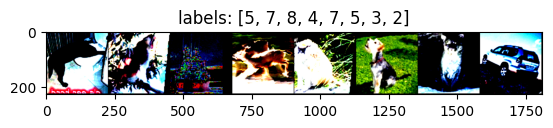

In [13]:
# DataLoader에서 배치 하나 꺼내기
xb, yb = next(iter(train_dl))

print("xb type:", type(xb))
print("xb shape:", xb.shape)  # [32, 3, 224, 224]
print("yb shape:", yb.shape)  # [32]
print("yb:", yb)              # 라벨 32개

# 첫 번째 이미지 시각화
show(xb[0], yb[0])

# 배치에서 8장만 그리드로 출력
x_grid = utils.make_grid(xb[:8], nrow=8, padding=2)
show(x_grid, yb[:8].tolist())


In [14]:
# Model Train
def train_val(model, params):
    num_epochs = params['num_epochs'] # 총 학습 횟수
    loss_func = params['loss_func'] # loss 함수
    opt = params['optimizer'] # optimizer
    train_dl = params['train_dl'] # 학습 데이터로더
    val_dl = params['val_dl'] # 검증 데이터로더
    sanity_check = params['sanity_check'] # 디버깅용 샘플만 돌릴지 여부
    lr_scheduler = params['lr_scheduler'] # 학습률 스케줄러
    path2weights = params['path2weights'] # 학습 완료 모델 저장 경로

    # 학습 및 검증 loss와 metric을 기록할 딕셔너리 초기화
    loss_history = {'train':[], 'val':[]}
    metric_history = {'train':[], 'val':[]}

    # validation loss 최소값 초기화(비교용)
    best_loss = float('inf') # 초기에는 무한대로 설정하여 첫 epoch에서 갱신 가능

    # 학습 시작 시간 기록
    start_time = time.time()

    for epoch in range(num_epochs): # 현재 epoch 반복
        current_lr = get_lr(opt)
        print("Epoch {}/{}, current lr={}".format(epoch, num_epochs-1, current_lr))

        model.train() # 학습 모드 설정(Dropout, BatchNorm 활성화)
        train_loss, train_metric = loss_epoch(model, loss_func, train_dl, sanity_check, opt)
        loss_history['train'].append(train_loss) # 학습 데이터로 loss, metric 계산
        metric_history['train'].append(train_metric) # 학습 loss와 metric 기록

        model.eval() # 모델을 평가모드로 설정(Dropout, BatchNorm 비활성화)
        with torch.no_grad():
            val_loss, val_metric = loss_epoch(model, loss_func, val_dl, sanity_check)

        loss_history['val'].append(val_loss)
        metric_history['val'].append(val_metric)

        # best_loss 갱신
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), path2weights)
            print("Get Best val_loss")

        lr_scheduler.step() # val_loss 필요 없음
        print('train loss: %.6f, val loss: %.6f, accuracy: %.2f, time:%.4fmin' 
              %(train_loss, val_loss, 100*val_metric, (time.time()-start_time)/60))
        print('-'*10)

    return model, loss_history, metric_history


In [15]:
# define the training parameters
params_train = {
    'num_epochs':350,
    'optimizer':opt,
    'loss_func': loss_func,
    'train_dl': train_dl,
    'val_dl': val_dl,
    'sanity_check': False,
    'lr_scheduler': lr_scheduler,
    'path2weights': './models/weights.pt',
}

# create the directory that stores weights.pt
# 지정한 경로가 폴더에 없으면 새로 생성하는 함수 
def createFolder(directory):
    try:
        if not os.path.exists(directory):
            os.makedirs(directory)
    except OSError:
        print('Error')

createFolder('./models')

model, loss_hist, metric_hist = train_val(model, params_train) # 학습 시작


Epoch 0/349, current lr=0.003


Get Best val_loss
train loss: 2.501310, val loss: 3.618918, accuracy: 21.82, time:0.8998min
----------
Epoch 1/349, current lr=0.0029999395742563066
Get Best val_loss
train loss: 2.095283, val loss: 2.277061, accuracy: 27.44, time:1.8006min
----------
Epoch 2/349, current lr=0.0029997583018935873
train loss: 1.997619, val loss: 2.429832, accuracy: 23.50, time:2.6982min
----------
Epoch 3/349, current lr=0.002999456197516532
train loss: 1.997274, val loss: 3.465837, accuracy: 25.36, time:3.6016min
----------
Epoch 4/349, current lr=0.0029990332854649823
Get Best val_loss
train loss: 1.933810, val loss: 1.884370, accuracy: 32.30, time:4.4856min
----------
Epoch 5/349, current lr=0.0029984895998119722
Get Best val_loss
train loss: 1.879581, val loss: 1.862494, accuracy: 35.90, time:5.3808min
----------
Epoch 6/349, current lr=0.0029978251843609817
Get Best val_loss
train loss: 1.838640, val loss: 1.777105, accuracy: 39.44, time:6.2677min
----------
Epoch 7/349, current lr=0.00299704009264

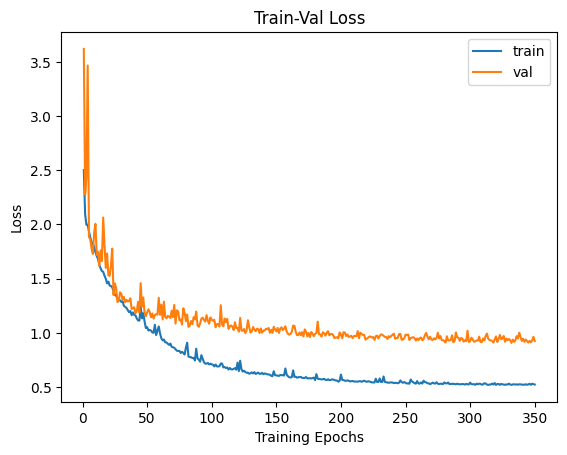

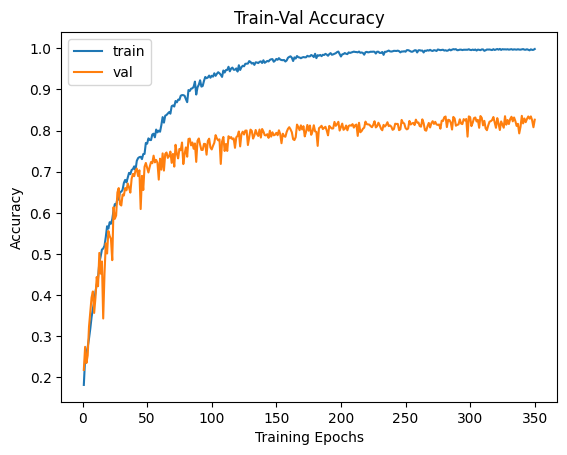

In [16]:
# Train-Validation Progress
num_epochs = params_train["num_epochs"]

# plot loss progress
plt.title("Train-Val Loss")
plt.plot(range(1, num_epochs+1), loss_hist["train"], label="train")
plt.plot(range(1, num_epochs+1), loss_hist["val"], label="val")
plt.ylabel("Loss")
plt.xlabel("Training Epochs")
plt.legend()
plt.show()

# plot accuracy progress
plt.title("Train-Val Accuracy")
plt.plot(range(1,num_epochs+1), metric_hist["train"], label="train")
plt.plot(range(1, num_epochs+1), metric_hist["val"], label="val")
plt.ylabel("Accuracy")
plt.xlabel("Training Epochs")
plt.legend()
plt.show()


In [17]:
print(f'최종 val accuracy: {100*metric_hist["val"][-1]:.2f}%')
print(f'최고 val accuracy: {100*max(metric_hist["val"]):.2f}%')

최종 val accuracy: 82.64%
최고 val accuracy: 83.58%
